In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import rioxarray

In [2]:
# read elevation change file
elev_file = "2013-2012.tif"
with rasterio.open(elev_file) as src:
    elev_change = src.read(1).astype(float)
    nodata_elev = src.nodata
    if nodata_elev is not None:
        elev_change[elev_change == nodata_elev] = np.nan

# read aspect file (.sdat format)
aspect_file = "2012_aspect.sdat"
aspect_da = rioxarray.open_rasterio(aspect_file)

aspect = aspect_da.values[0].astype(float)

# replace NoData with NaN
if aspect_da.rio.nodata is not None:
    aspect[aspect == aspect_da.rio.nodata] = np.nan

In [3]:
# match aspect file to elevation file (same resolution and extent)
# elevation raster as the target
aspect_resampled = aspect_da.rio.reproject_match(rioxarray.open_rasterio(elev_file))

aspect = aspect_resampled.values[0].astype(float)

# replace NoData with NaN
if aspect_resampled.rio.nodata is not None:
    aspect[aspect == aspect_resampled.rio.nodata] = np.nan

# mask out pixels if EITHER elevation or aspect is NaN
valid_mask = ~np.isnan(elev_change) & ~np.isnan(aspect)
x = elev_change[valid_mask]
y = aspect[valid_mask]

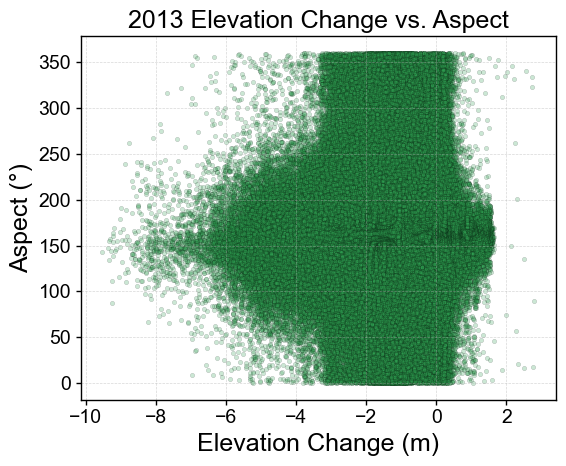

In [4]:
# plot scatterplot
plt.rcParams.update({
    "font.family": "Arial", 
    "font.size": 18, 
    "axes.labelsize": 18, 
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14, 
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})
plt.figure(figsize=(6, 5))
plt.scatter(
    x, y,
    s=10,
    alpha=0.25,
    color="#31a354",
    edgecolor="k",
    linewidth=0.3
)
plt.xlabel("Elevation Change (m)")
plt.ylabel("Aspect (\u00B0)")
plt.title("2013 Elevation Change vs. Aspect")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()

plt.show()